In [181]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# PHẦN 1: TIỀN XỬ LÝ DỮ LIỆU
# BƯỚC 1: ĐỌC VÀ MÔ TẢ DỮ LIỆU
# Đọc file CSV
df = pd.read_csv('E:\\smartphones_data.csv.csv')

# Kiểm tra kích thước và liệt kê các cột
print(f"Kích thước ban đầu: {df.shape[0]} dòng, {df.shape[1]} cột")
print("\nDanh sách các cột:")
print(df.columns.tolist())

# Kiểm tra kiểu dữ liệu
print("\nThông tin kiểu dữ liệu:")
print(df.info())

Kích thước ban đầu: 3260 dòng, 20 cột

Danh sách các cột:
['brand_name', 'Name', 'Price', 'RAM', 'OS', 'storage', 'Battery_cap', 'has_fast_charging', 'has_fingerprints', 'has_nfc', 'has_5g', 'processor_brand', 'num_core', 'primery_rear_camera', 'Num_Rear_Cameras', 'primery_front_camera', 'num_front_camera', 'display_size(inch)', 'refresh_rate(hz)', 'display_types']

Thông tin kiểu dữ liệu:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3260 entries, 0 to 3259
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   brand_name            3260 non-null   object 
 1   Name                  3260 non-null   object 
 2   Price                 3260 non-null   int64  
 3   RAM                   3260 non-null   float64
 4   OS                    3260 non-null   object 
 5   storage               3260 non-null   float64
 6   Battery_cap           3260 non-null   int64  
 7   has_fast_charging     3260 non-null 

In [182]:
df = df.drop_duplicates()
print(f"\nKích thước sau khi xóa dữ liệu trùng lặp: {df.shape[0]} dòng, {df.shape[1]} cột")


Kích thước sau khi xóa dữ liệu trùng lặp: 3260 dòng, 20 cột


In [183]:
# BƯỚC 2: PHÁT HIỆN VÀ XỬ LÝ DỮ LIỆU LỖI
print("\nSố lượng missing values trước khi xử lý:")
print(df.isnull().sum())


Số lượng missing values trước khi xử lý:
brand_name                 0
Name                       0
Price                      0
RAM                        0
OS                         0
storage                    0
Battery_cap                0
has_fast_charging          0
has_fingerprints         726
has_nfc                  726
has_5g                   726
processor_brand            0
num_core                 175
primery_rear_camera        0
Num_Rear_Cameras           0
primery_front_camera       0
num_front_camera           0
display_size(inch)         0
refresh_rate(hz)        1731
display_types              0
dtype: int64


In [184]:
# Xử lý giá trị thiếu (missing values)
# điền median (trung vị) cho các cột số và mode (yếu tố xuất hiện nhiều nhất) cho cột phân loại

numeric_cols = df.select_dtypes(include=[np.number]).columns
categorical_cols = df.select_dtypes(exclude=[np.number]).columns

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Xử lý giá trị không hợp lệ & dị thường

# Giá RAM, storage, Battery_cap không được âm hoặc bằng 0
df = df[(df['RAM'] > 0) & (df['storage'] > 0) & (df['Battery_cap'] > 0)]
# Số lượng camera không được bằng 0
df = df[(df['Num_Rear_Cameras'] > 0) & (df['num_front_camera'] > 0)]
# Kích thước màn hình <= 8 inch
df = df[df['display_size(inch)'] <= 8]

# Xử lý kiểu dữ liệu các biến Categorical Yes/No -> 1/0
binary_cols = ['has_fast_charging', 'has_fingerprints', 'has_nfc', 'has_5g']
for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0}).fillna(0).astype(int)

# Xử lý cột OS
# Gom thành 3 nhóm rõ ràng: 'android', 'ios', và 'other'
df['OS'] = df['OS'].str.lower()
df['OS'] = df['OS'].apply(lambda x: x if pd.notna(x) and x in ['android', 'ios'] else 'other')

In [185]:
# BẢNG THỐNG KÊ MÔ TẢ CÁC BIẾN SỐ
print("\n--- BẢNG THỐNG KÊ MÔ TẢ CÁC BIẾN DẠNG SỐ ---")

# Lọc ra các cột dạng số
numeric_cols_for_desc = df.select_dtypes(include=[np.number])
summary_stats = numeric_cols_for_desc.describe().round(2)
print(summary_stats)


--- BẢNG THỐNG KÊ MÔ TẢ CÁC BIẾN DẠNG SỐ ---
           Price      RAM  storage  Battery_cap  has_fast_charging  \
count    3259.00  3259.00  3259.00      3259.00            3259.00   
mean    20138.48     5.06   111.92      4163.01               0.47   
std     24024.50     3.25   126.72      1312.33               0.50   
min      2500.00     0.25     0.31      1100.00               0.00   
25%      7490.00     3.00    32.00      3005.00               0.00   
50%     11999.00     4.00    64.00      4500.00               0.00   
75%     21999.00     8.00   128.00      5000.00               1.00   
max    200999.00    24.00  1024.00     22000.00               1.00   

       has_fingerprints  has_nfc   has_5g  num_core  primery_rear_camera  \
count           3259.00  3259.00  3259.00   3259.00              3259.00   
mean               0.96     0.26     0.31      7.14                32.65   
std                0.20     0.44     0.46      1.65                29.40   
min                

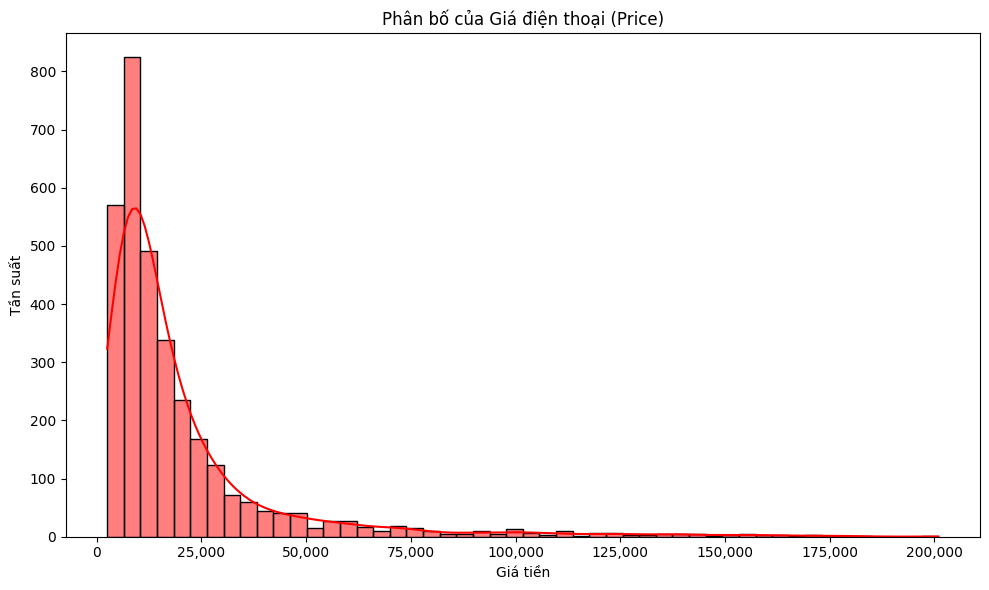

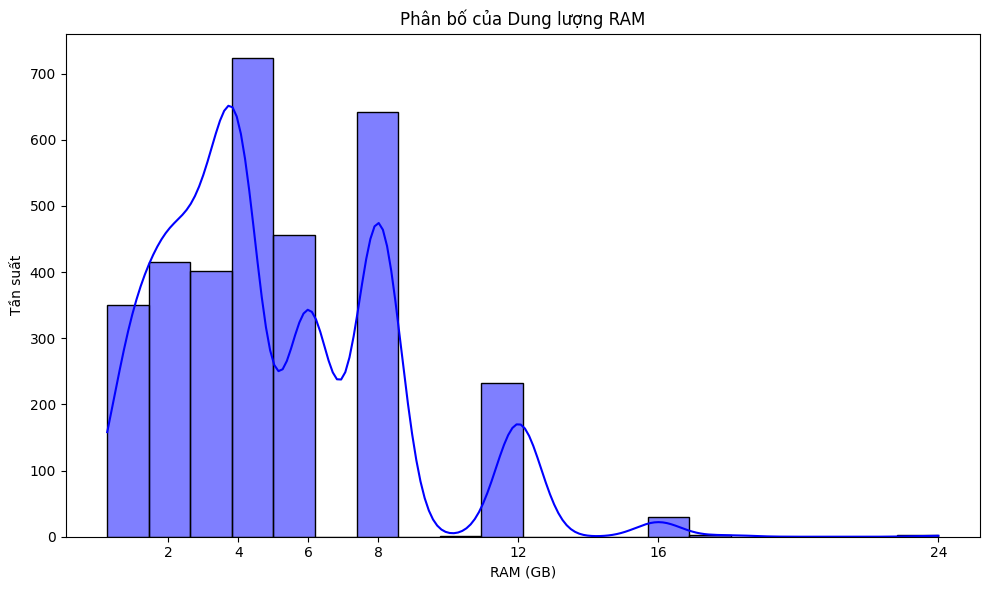

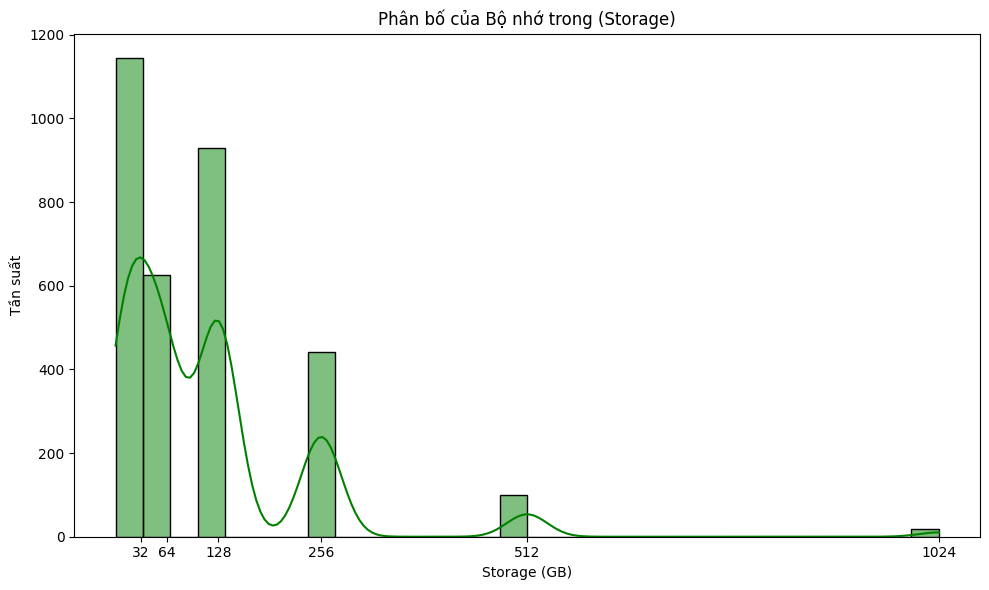

In [186]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

# Thiết lập style đồ thị
sns.set_theme(style="whitegrid")
plt.style.use('default')

# Hàm định dạng dấu phẩy hàng nghìn
comma_formatter = FuncFormatter(lambda x, pos: f"{int(x):,}")

# 1. Biểu đồ Giá điện thoại (Price)
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Price', kde=True, color='red', bins=50, edgecolor='black')
plt.gca().xaxis.set_major_formatter(comma_formatter) # Thêm dấu phẩy hàng nghìn
plt.title('Phân bố của Giá điện thoại (Price)')
plt.xlabel('Giá tiền')
plt.ylabel('Tần suất')
plt.tight_layout()
plt.show()

# 2. Biểu đồ Dung lượng RAM
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='RAM', kde=True, color='blue', bins=20, edgecolor='black')
plt.xticks([2, 4, 6, 8, 12, 16, 24]) # Ép hiển thị đúng các mốc RAM
plt.title('Phân bố của Dung lượng RAM')
plt.xlabel('RAM (GB)')
plt.ylabel('Tần suất')
plt.tight_layout()
plt.show()

# 3. Biểu đồ Bộ nhớ trong (Storage)
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='storage', kde=True, color='green', bins=30, edgecolor='black')
plt.xticks([32, 64, 128, 256, 512, 1024]) # Ép hiển thị đúng các mốc ROM
plt.title('Phân bố của Bộ nhớ trong (Storage)')
plt.xlabel('Storage (GB)')
plt.ylabel('Tần suất')
plt.tight_layout()
plt.show()


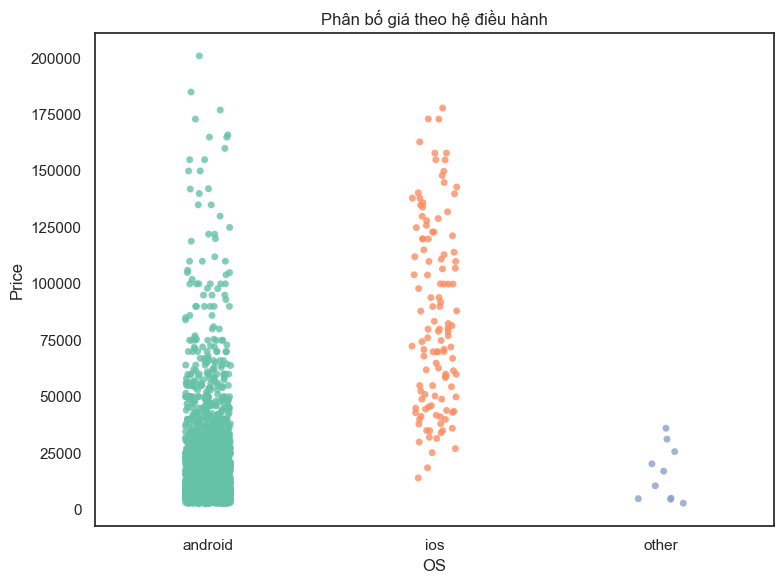

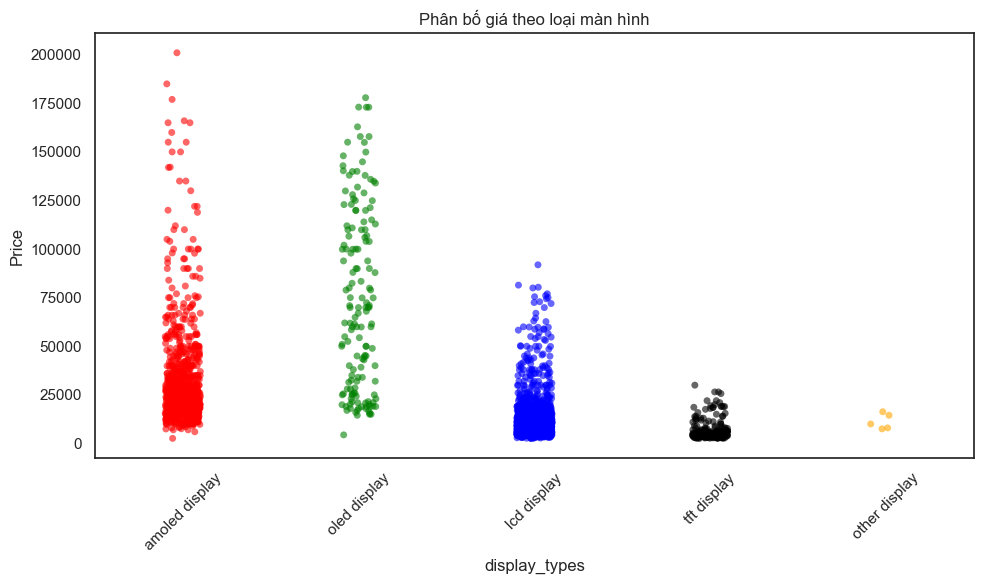

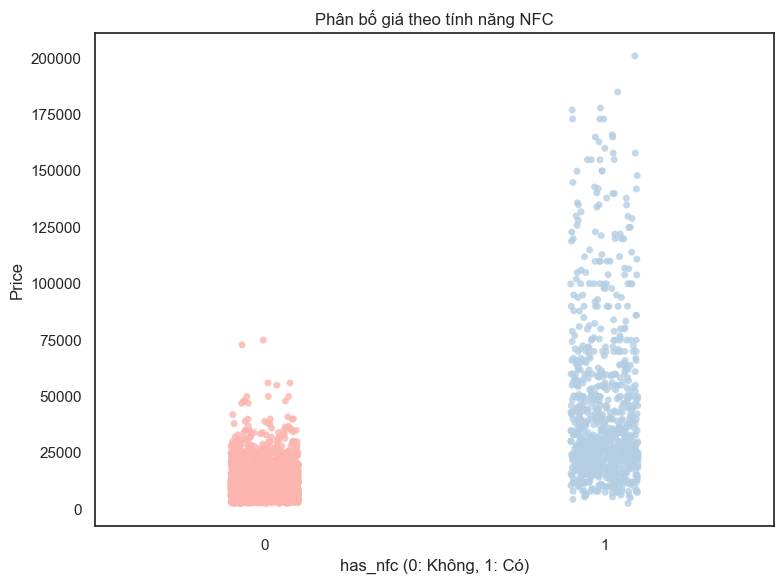

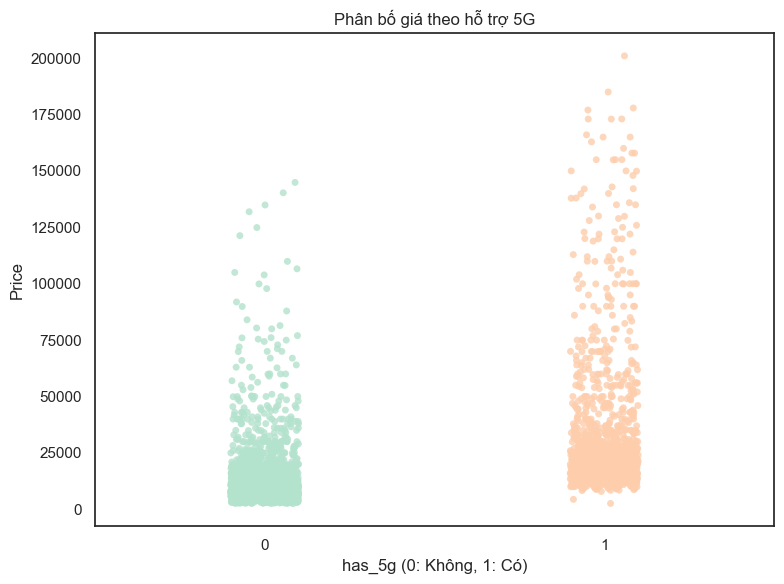

In [187]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="white")
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'

# 1. OS vs Price
plt.figure(figsize=(8, 6))
sns.stripplot(data=df, x='OS', y='Price',
              jitter=True, alpha=0.8, palette='Set2')
plt.title('Phân bố giá theo hệ điều hành')
plt.xlabel('OS')
plt.ylabel('Price')
plt.tight_layout()
plt.show()

# 2. display_types vs Price
plt.figure(figsize=(10, 6))

palette_custom = {
    'amoled display': 'red',
    'oled display': 'green',
    'lcd display': 'blue',
    'tft display': 'black',
    'other display': 'orange'
}

sns.stripplot(
    data=df,
    x='display_types',
    y='Price',
    jitter=True,
    alpha=0.6,
    palette=palette_custom
)

plt.title('Phân bố giá theo loại màn hình')
plt.xlabel('display_types')
plt.ylabel('Price')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 3. has_nfc vs Price
plt.figure(figsize=(8, 6))
sns.stripplot(data=df, x='has_nfc', y='Price',
              jitter=True, alpha=0.8, palette='Pastel1')
plt.title('Phân bố giá theo tính năng NFC')
plt.xlabel('has_nfc (0: Không, 1: Có)')
plt.ylabel('Price')
plt.tight_layout()
plt.show()

# 4. has_5g vs Price
plt.figure(figsize=(8, 6))
sns.stripplot(data=df, x='has_5g', y='Price',
              jitter=True, alpha=0.8, palette='Pastel2')
plt.title('Phân bố giá theo hỗ trợ 5G')
plt.xlabel('has_5g (0: Không, 1: Có)')
plt.ylabel('Price')
plt.tight_layout()
plt.show()

In [188]:
# BƯỚC 3: CHUYỂN ĐỔI DỮ LIỆU VỀ DẠNG PHÙ HỢP

# Bỏ cột 'Name'
if 'Name' in df.columns:
    df = df.drop(columns=['Name'])

# One-Hot Encoding cho biến categorical: brand_name, processor_brand, display_types
cols_to_encode = ['brand_name', 'processor_brand', 'display_types', 'OS']
df = pd.get_dummies(df, columns=cols_to_encode, drop_first=False)

# Ép kiểu boolean True/False từ get_dummies về dạng 1/0 (số nguyên)
for col in df.select_dtypes(include=['boolean']).columns:
    df[col] = df[col].astype(int)

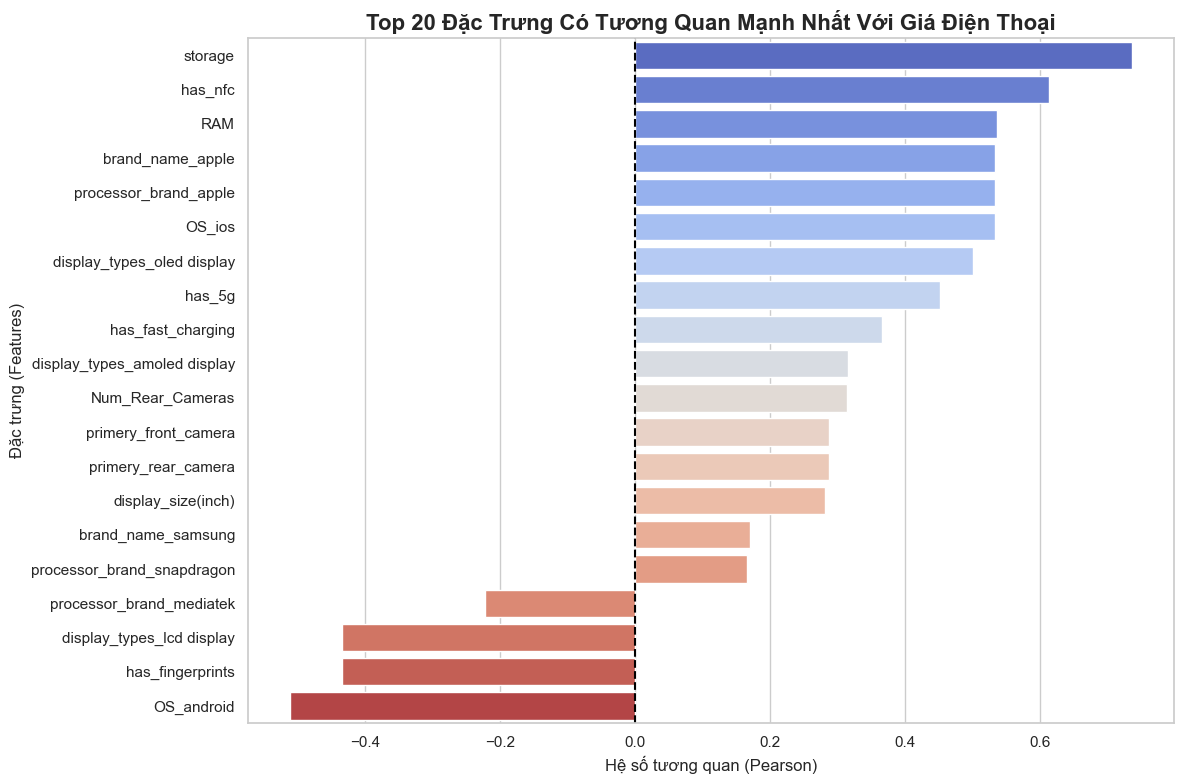

In [189]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('default')
sns.set_theme(style="whitegrid")

plt.figure(figsize=(12, 8))

# Lọc các biến dạng số
numeric_df = df.select_dtypes(include=['int64', 'float64'])
# Tính tương quan với cột 'Price'
corr_with_price = numeric_df.corr()['Price'].drop('Price')
# Top 20 biến có sức ảnh hưởng mạnh nhất
top_features = corr_with_price.abs().nlargest(20).index
# Lọc lại data theo top_features và sắp xếp từ cao xuống thấp
corr_filtered = corr_with_price[top_features].sort_values(ascending=False)
sns.barplot(x=corr_filtered.values, y=corr_filtered.index, palette='coolwarm')

plt.title('Top 20 Đặc Trưng Có Tương Quan Mạnh Nhất Với Giá Điện Thoại', fontsize=16, fontweight='bold')
plt.xlabel('Hệ số tương quan (Pearson)', fontsize=12)
plt.ylabel('Đặc trưng (Features)', fontsize=12)
plt.axvline(x=0, color='black', linestyle='--')

plt.tight_layout()
plt.show()

In [190]:
# BƯỚC 4: CHUẨN HÓA GIÁ TRỊ
scaler = StandardScaler()

# Chỉ chuẩn hóa các cột Numeric đầu vào, không chuẩn hóa đầu ra (Price) và các cột Binary (0/1)
numeric_features_to_scale = [
    'RAM', 'storage', 'Battery_cap', 'num_core',
    'primery_rear_camera', 'Num_Rear_Cameras',
    'primery_front_camera', 'num_front_camera',
    'display_size(inch)', 'refresh_rate(hz)'
]

# Thực hiện chuẩn hóa Z-score: z = (x-mean)/s
df[numeric_features_to_scale] = scaler.fit_transform(df[numeric_features_to_scale])

print(f"\n Kích thước dữ liệu sau khi xử lí: {df.shape[0]} dòng, {df.shape[1]} cột")
print(df.head())
print(df.describe())


 Kích thước dữ liệu sau khi xử lí: 3259 dòng, 71 cột
    Price       RAM   storage  Battery_cap  has_fast_charging  \
0   34999  0.903491  0.126929     1.400004                  1   
1   21999  0.903491  0.126929     1.400004                  1   
2   27999  0.903491  0.126929     1.400004                  1   
3  129999  2.133784  1.137190     0.637884                  1   
4   22999  0.903491  0.126929     1.018944                  1   

   has_fingerprints  has_nfc  has_5g  num_core  primery_rear_camera  ...  \
0                 1        0       1  0.522724             0.590197  ...   
1                 1        0       1  0.522724             0.590197  ...   
2                 1        0       1  0.522724             0.590197  ...   
3                 1        1       1  0.522724             5.692910  ...   
4                 1        0       1  0.522724             0.590197  ...   

   processor_brand_tru-mediatek  processor_brand_unisoc  \
0                             0        

Kích thước dữ liệu gốc: (3259, 70)


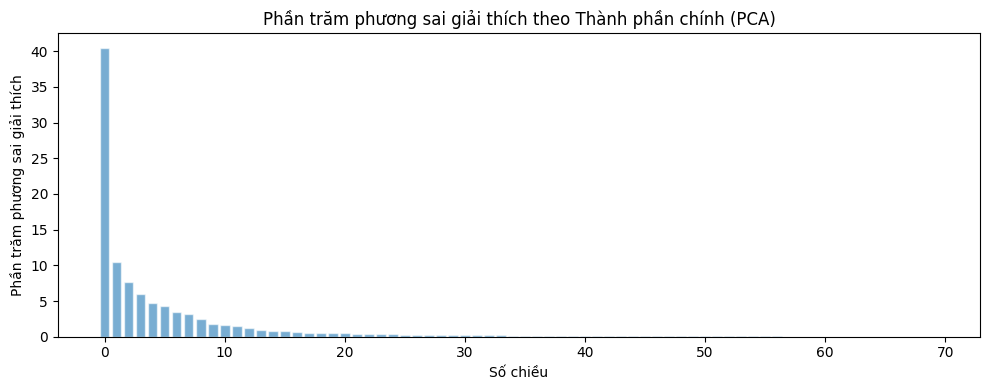

In [191]:
import seaborn as sns
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

# GIẢM CHIỀU BẰNG 2 PHƯƠNG PHÁP (PCA & LDA)
X = df.drop(columns=['Price'])
y = df['Price']

# Tạo y_class
y_class = pd.qcut(df['Price'], q=3, labels=['Low', 'Medium', 'High'])
print(f"Kích thước dữ liệu gốc: {X.shape}")

# Giảm chiều bằng LDA (2 chiều)
lda = LinearDiscriminantAnalysis(n_components=2)
X_lda = lda.fit_transform(X, y_class)

# Giảm chiều bằng PCA
pca = PCA()
X_pca = pca.fit_transform(X)


plt.style.use('default')
# Lấy mảng tỷ lệ phương sai của từng cột và nhân 100 để ra phần trăm (%)
explained_variance_pct = pca.explained_variance_ratio_ * 100

# Vẽ biểu đồ Bar Chart
plt.figure(figsize=(10, 4))

plt.bar(
    range(len(explained_variance_pct)),
    explained_variance_pct,
    alpha=0.6,
    color='tab:blue',
    edgecolor='white'
)

plt.xlabel('Số chiều')
plt.ylabel('Phần trăm phương sai giải thích')
plt.title('Phần trăm phương sai giải thích theo Thành phần chính (PCA)')

plt.tight_layout()
plt.show()

In [192]:
# 1. Tính % mất mát thông tin khi chỉ dùng 4 thành phần chính (PC1 -> PC4)
retained_variance_4pcs = np.sum(pca.explained_variance_ratio_[:4]) * 100
loss_variance_4pcs = 100 - retained_variance_4pcs

print("\n" + "="*50)
print(f"Thông tin giữ lại (4 PC đầu): {retained_variance_4pcs:.2f}%")
print(f"Phần trăm thông tin mất mát (khi dùng 4 PC đầu): {loss_variance_4pcs:.2f}%")
print("="*50)

# Tìm các biến ảnh hưởng nhất đến từng thành phần (PC1 đến PC4)
feature_names = X.columns
n_pcs = 4
top_n_features = 3

print("\nCÁC BIẾN GỐC ẢNH HƯỞNG NHẤT ĐẾN 4 THÀNH PHẦN CHÍNH (PC1 - PC4):")

for i in range(n_pcs):
    # Dùng trị tuyệt đối để đánh giá độ lớn của sức ảnh hưởng
    importance = np.abs(pca.components_[i])
    # Lấy ra index của top các biến có sức ảnh hưởng lớn nhất
    top_indices = np.argsort(importance)[::-1][:top_n_features]

    print(f"\n[PC{i+1}] (giải thích {pca.explained_variance_ratio_[i]*100:.2f}% phương sai):")
    for rank, idx in enumerate(top_indices):
        feature = feature_names[idx]
        weight = pca.components_[i][idx] #Lấy trọng số
        print(f"   {rank+1}. {feature:<20} | Trọng số: {weight:.4f}")


Thông tin giữ lại (4 PC đầu): 64.69%
Phần trăm thông tin mất mát (khi dùng 4 PC đầu): 35.31%

CÁC BIẾN GỐC ẢNH HƯỞNG NHẤT ĐẾN 4 THÀNH PHẦN CHÍNH (PC1 - PC4):

[PC1] (giải thích 40.46% phương sai):
   1. RAM                  | Trọng số: 0.3868
   2. display_size(inch)   | Trọng số: 0.3661
   3. Num_Rear_Cameras     | Trọng số: 0.3477

[PC2] (giải thích 10.53% phương sai):
   1. refresh_rate(hz)     | Trọng số: 0.6274
   2. Battery_cap          | Trọng số: -0.3245
   3. storage              | Trọng số: 0.3082

[PC3] (giải thích 7.67% phương sai):
   1. num_front_camera     | Trọng số: 0.9333
   2. refresh_rate(hz)     | Trọng số: -0.2373
   3. num_core             | Trọng số: 0.1325

[PC4] (giải thích 6.02% phương sai):
   1. refresh_rate(hz)     | Trọng số: 0.6148
   2. num_core             | Trọng số: 0.5400
   3. storage              | Trọng số: -0.3536


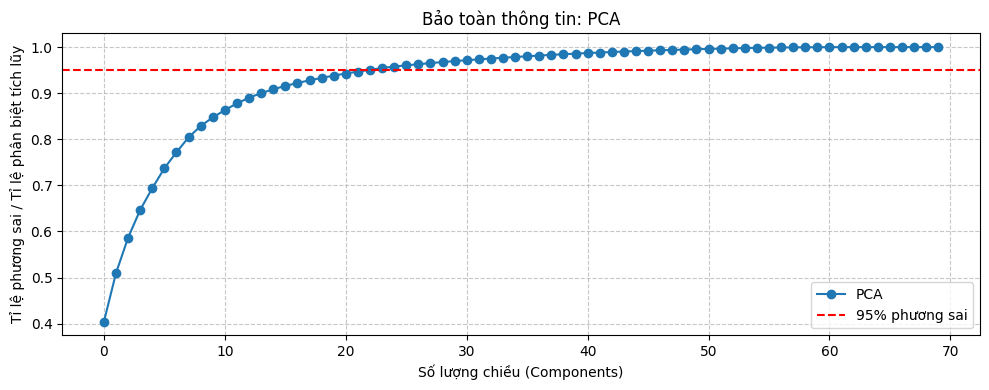

Số chiều chính xác cần để đạt >= 95% phương sai là: 23


In [193]:
plt.figure(figsize=(10, 4))

# Tính toán mảng phương sai tích lũy
pca_variance = np.cumsum(pca.explained_variance_ratio_)

# Vẽ đồ thị
plt.plot( pca_variance, marker='o', label='PCA')
plt.axhline(y=0.95, color='red', linestyle='--', label='95% phương sai')
plt.xlabel('Số lượng chiều (Components)')
plt.ylabel('Tỉ lệ phương sai / Tỉ lệ phân biệt tích lũy')
plt.title('Bảo toàn thông tin: PCA')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1

print(f"Số chiều chính xác cần để đạt >= 95% phương sai là: {n_components_95}")

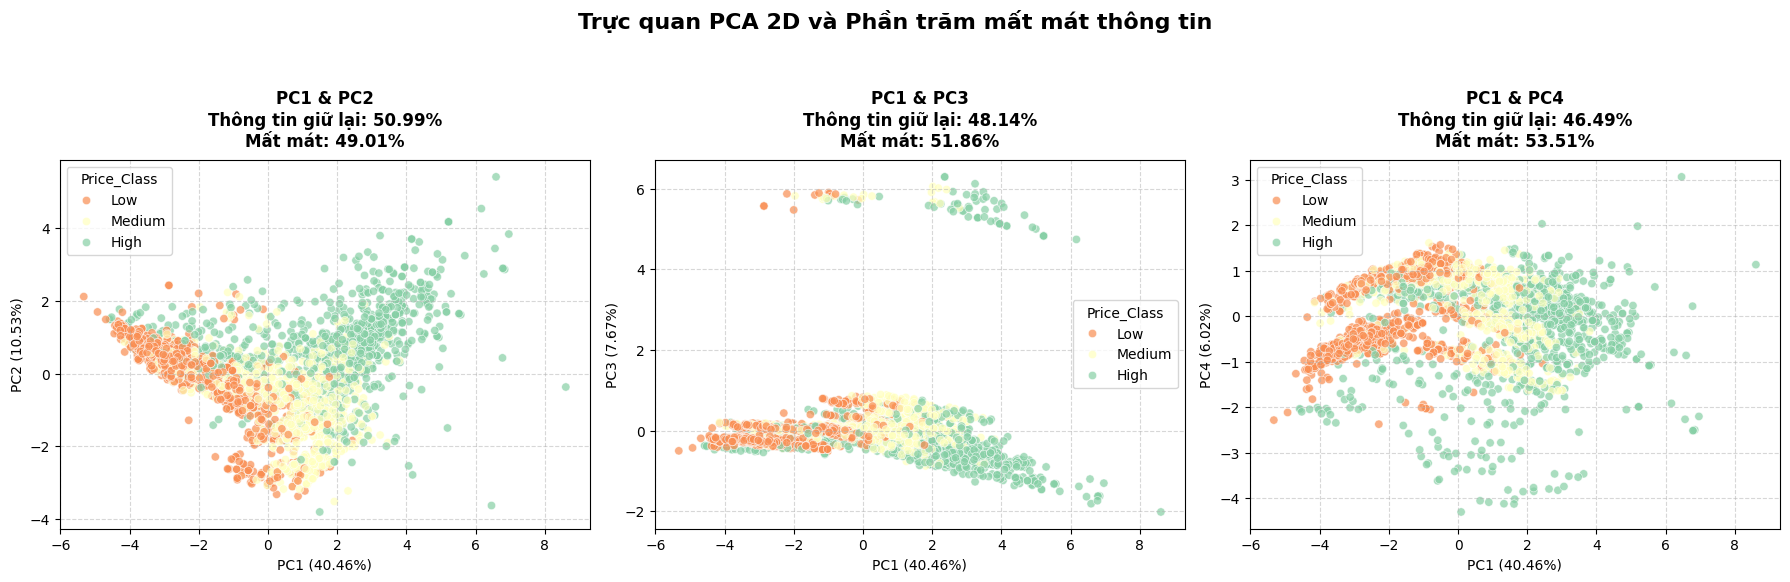

In [194]:
# Tạo DataFrame cho 4 thành phần chính đầu tiên
df_pca = pd.DataFrame(X_pca[:, :4], columns=['PC1', 'PC2', 'PC3', 'PC4'])
df_pca['Price_Class'] = y_class.values

# Lấy tỷ lệ phương sai (phần trăm) của từng thành phần
var_ratios = pca.explained_variance_ratio_ * 100

pairs = [
    ('PC1', 'PC2', 0, 1),
    ('PC1', 'PC3', 0, 2),
    ('PC1', 'PC4', 0, 3)
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

for i, (col_x, col_y, idx_x, idx_y) in enumerate(pairs):
    # Tính toán thông tin giữ lại và mất mát
    retained_info = var_ratios[idx_x] + var_ratios[idx_y]
    loss_info = 100 - retained_info

    sns.scatterplot(
        data=df_pca,
        x=col_x,
        y=col_y,
        hue='Price_Class',
        palette='Spectral',
        alpha=0.7,
        ax=axes[i]
    )

    title = f"{col_x} & {col_y}\nThông tin giữ lại: {retained_info:.2f}%\nMất mát: {loss_info:.2f}%"
    axes[i].set_title(title, fontsize=12, fontweight='bold', pad=10)
    axes[i].grid(True, linestyle='--', alpha=0.5)

    axes[i].set_xlabel(f"{col_x} ({var_ratios[idx_x]:.2f}%)")
    axes[i].set_ylabel(f"{col_y} ({var_ratios[idx_y]:.2f}%)")

plt.suptitle('Trực quan PCA 2D và Phần trăm mất mát thông tin', fontsize=16, fontweight='bold', y=1.05)

plt.tight_layout()
plt.show()

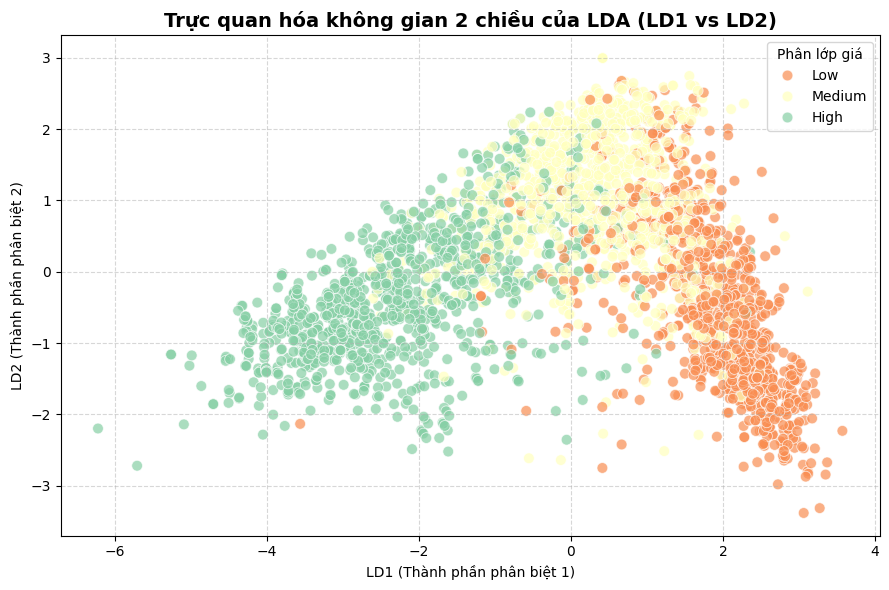

In [195]:
plt.figure(figsize=(9, 6))

# Tạo DataFrame chứa cả LD1, LD2 và nhãn class
df_lda_2d = pd.DataFrame({
    'LD1': X_lda[:, 0],
    'LD2': X_lda[:, 1],
    'Price_Class': y_class
})

# Vẽ biểu đồ Scatter 2D
sns.scatterplot(
    data=df_lda_2d,
    x='LD1',
    y='LD2',
    hue='Price_Class',
    palette='Spectral',
    alpha=0.7,
    s=60,
    edgecolor='w'
)

plt.title('Trực quan hóa không gian 2 chiều của LDA (LD1 vs LD2)', fontsize=14, fontweight='bold')
plt.xlabel('LD1 (Thành phần phân biệt 1)')
plt.ylabel('LD2 (Thành phần phân biệt 2)')
plt.legend(title='Phân lớp giá')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

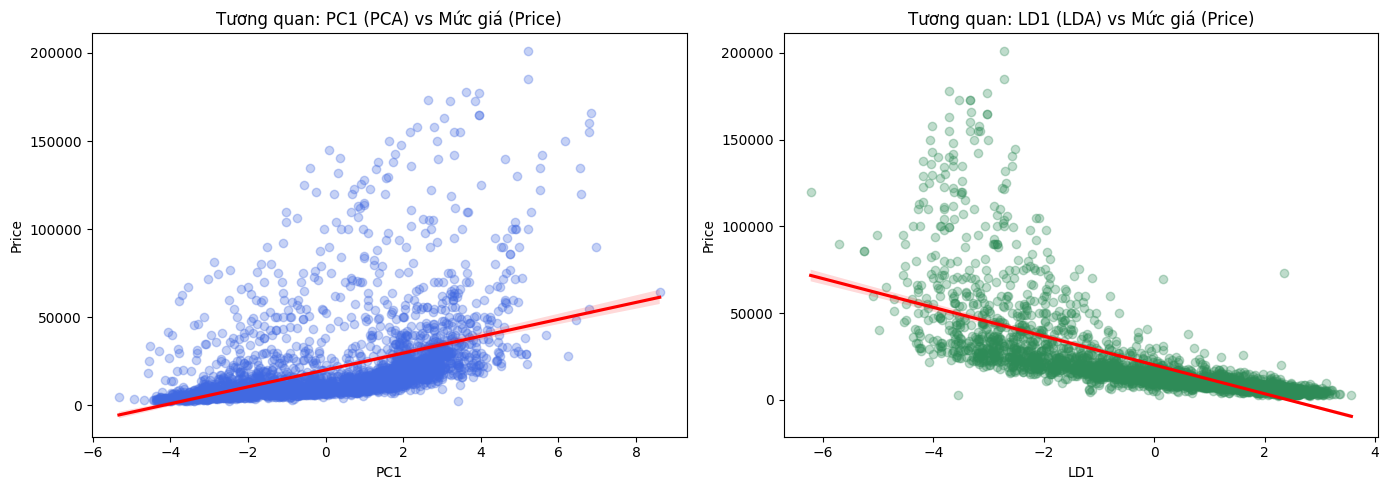

In [196]:
# MỐI QUAN HỆ CHIỀU CHÍNH VỚI ĐẦU RA
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PC1 của PCA với Price thực tế
sns.regplot(x=X_pca[:, 0], y=y, ax=axes[0], scatter_kws={'alpha':0.3, 'color': 'royalblue'}, line_kws={'color':'red'})
axes[0].set_title('Tương quan: PC1 (PCA) vs Mức giá (Price)')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('Price')

# LD1 của LDA với Price thực tế
sns.regplot(x=X_lda[:, 0], y=y, ax=axes[1], scatter_kws={'alpha':0.3, 'color': 'seagreen'}, line_kws={'color':'red'})
axes[1].set_title('Tương quan: LD1 (LDA) vs Mức giá (Price)')
axes[1].set_xlabel('LD1')
axes[1].set_ylabel('Price')

plt.tight_layout()
plt.show()

### 1.3. Phân tích hồi quy



K tốt nhất (theo 5-Fold CV): k = 4  |  R² trung bình = 0.8462


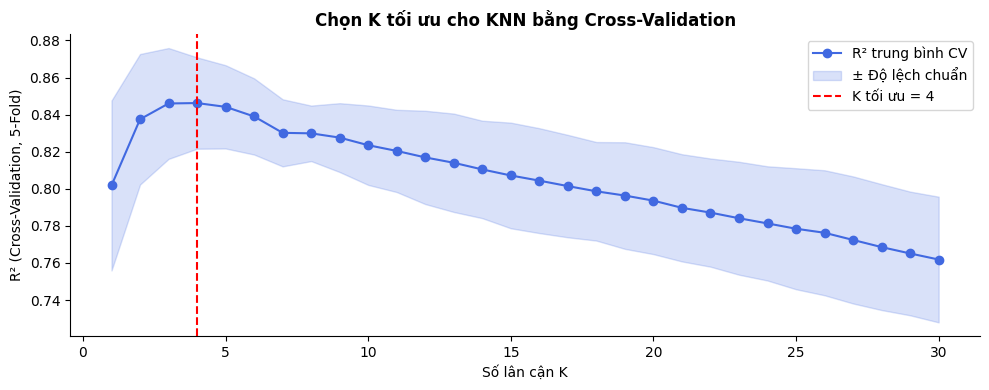


Số chiều PCA (1/3 gốc): 23

--- ĐÁNH GIÁ MÔ HÌNH HỒI QUY ---
Model                | Tỉ lệ | MAE Gốc (Train/Test)   | MSE Gốc (Train/Test)   | R2 Gốc (Train/Test)  | MAE PCA (Train/Test)   | MSE PCA (Train/Test)   | R2 PCA (Train/Test) 
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
  [PCA tỷ lệ 8:2] Phương sai giữ lại: 95.10%
Linear Regression    | 8:2   | 6785 / 7229      | 113931196 / 133611575      | 0.804 / 0.760      | 6952 / 7523      | 126643169 / 150617992      | 0.782 / 0.730
                     | 7:3   | 6903 / 7098      | 116515143 / 123622642      | 0.809 / 0.751      | 7089 / 7286      | 130514146 / 135039272      | 0.787 / 0.728
                     | 6:4   | 7086 / 7142      | 120495895 / 118730860      | 0.807 / 0.766      | 7371 / 7264      | 136708780 / 125955932      | 0.781 / 0.751
---------------------------------------------------------

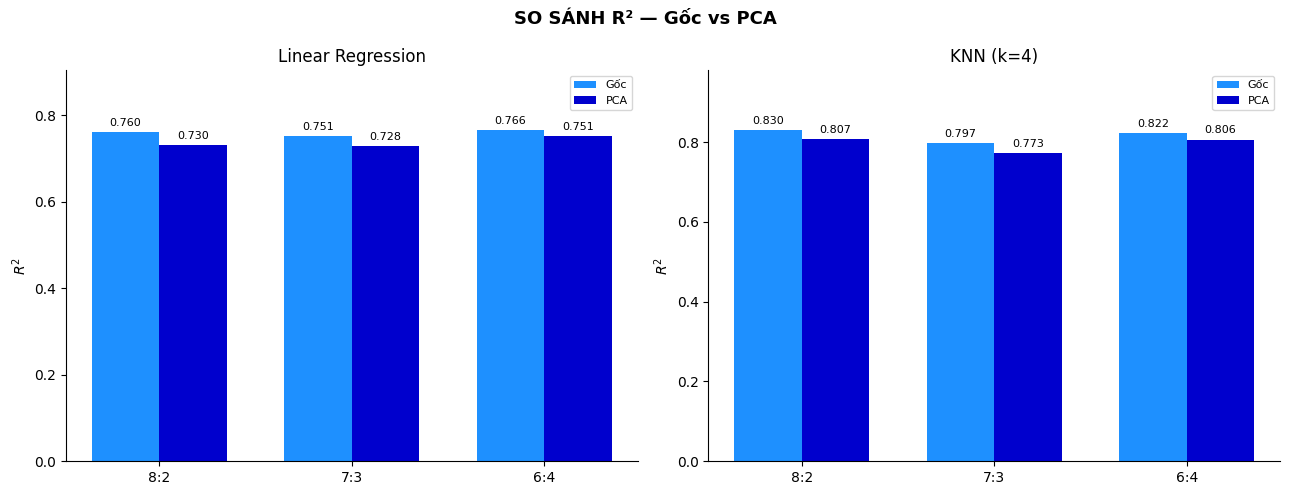

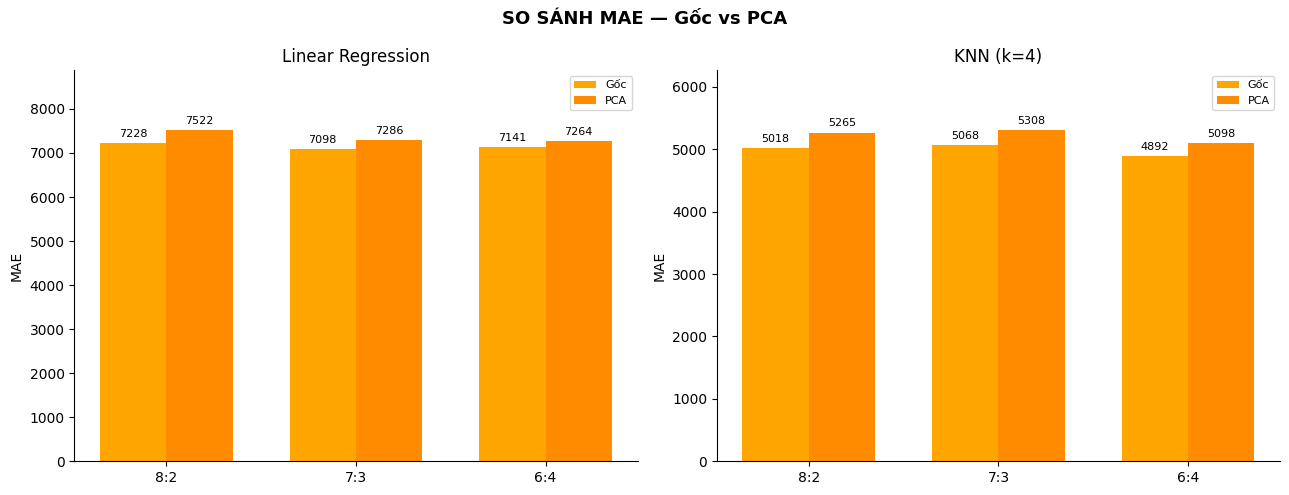

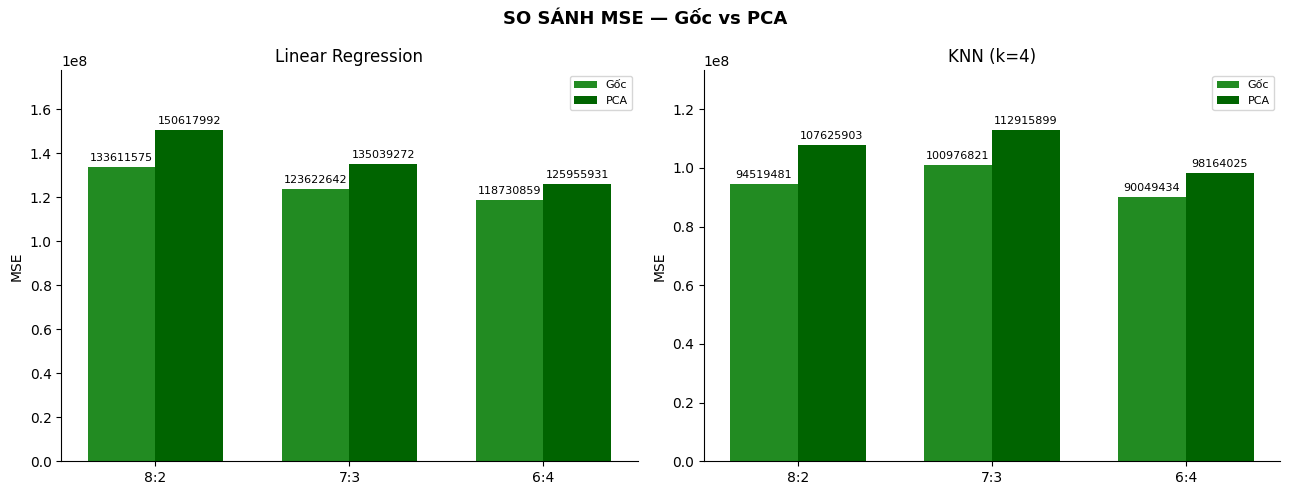

In [197]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.decomposition import PCA

# ──────────────────────────────────────────────────────────────
# BƯỚC 1: TỐI ƯU SỐ K CHO KNN BẰNG CROSS-VALIDATION (5-Fold)
# ──────────────────────────────────────────────────────────────
# Thử các giá trị k từ 1 đến 30 để tìm k tốt nhất
k_range = range(1, 31)
cv_scores_mean = []   # Lưu R2 trung bình theo từng k
cv_scores_std  = []   # Lưu độ lệch chuẩn R2 theo từng k

kf = KFold(n_splits=5, shuffle=True, random_state=42)   # 5-Fold CV

for k in k_range:
    knn_cv = KNeighborsRegressor(n_neighbors=k)
    # cross_val_score trả về mảng R2 của 5 fold; dùng scoring='r2'
    scores = cross_val_score(knn_cv, X, y, cv=kf, scoring='r2')
    cv_scores_mean.append(scores.mean())
    cv_scores_std.append(scores.std())

# Tìm k cho R2 trung bình cao nhất
best_k = k_range[np.argmax(cv_scores_mean)]
best_r2 = max(cv_scores_mean)
print(f"K tốt nhất (theo 5-Fold CV): k = {best_k}  |  R² trung bình = {best_r2:.4f}")

# Vẽ đồ thị chọn K tối ưu
fig_cv, ax_cv = plt.subplots(figsize=(10, 4))
ax_cv.plot(k_range, cv_scores_mean, marker='o', color='royalblue', label='R² trung bình CV')
ax_cv.fill_between(
    k_range,
    np.array(cv_scores_mean) - np.array(cv_scores_std),
    np.array(cv_scores_mean) + np.array(cv_scores_std),
    alpha=0.2, color='royalblue', label='± Độ lệch chuẩn'
)
ax_cv.axvline(x=best_k, color='red', linestyle='--', label=f'K tối ưu = {best_k}')
ax_cv.set_xlabel('Số lân cận K')
ax_cv.set_ylabel('R² (Cross-Validation, 5-Fold)')
ax_cv.set_title('Chọn K tối ưu cho KNN bằng Cross-Validation', fontweight='bold')
ax_cv.legend()
ax_cv.spines['top'].set_visible(False)
ax_cv.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

# ──────────────────────────────────────────────────────────────
# BƯỚC 2: GIẢM CHIỀU BẰNG PCA (fit RIÊNG trên từng tập train)
# ──────────────────────────────────────────────────────────────
# Số thành phần PCA = 1/3 số đặc trưng gốc
n_reduced = int(X.shape[1] / 3)
print(f"\nSố chiều PCA (1/3 gốc): {n_reduced}")

# ──────────────────────────────────────────────────────────────
# BƯỚC 3: HUẤN LUYỆN VÀ ĐÁNH GIÁ TRÊN 3 TỶ LỆ CHIA
# ──────────────────────────────────────────────────────────────
# test_size: 0.2 → train/test = 8:2, 0.3 → 7:3, 0.4 → 6:4
splits = [0.2, 0.3, 0.4]

# Dùng K tối ưu vừa tìm được cho KNN
models = {
    "Linear Regression": LinearRegression(),
    f"KNN (k={best_k})": KNeighborsRegressor(n_neighbors=best_k)
}

saved_results = {}   # Lưu y_test / y_pred của tỷ lệ 6:4 để vẽ đồ thị sau

# --- Khởi tạo danh sách lưu số liệu cho từng metric / model ---
lr_r2_goc,  lr_r2_pca  = [], []
lr_mae_goc, lr_mae_pca = [], []
lr_mse_goc, lr_mse_pca = [], []

knn_r2_goc,  knn_r2_pca  = [], []
knn_mae_goc, knn_mae_pca = [], []
knn_mse_goc, knn_mse_pca = [], []

print("\n--- ĐÁNH GIÁ MÔ HÌNH HỒI QUY ---")
header = (
    f"{'Model':<20} | {'Tỉ lệ':<5} | "
    f"{'MAE Gốc (Train/Test)':<22} | {'MSE Gốc (Train/Test)':<22} | {'R2 Gốc (Train/Test)':<20} | "
    f"{'MAE PCA (Train/Test)':<22} | {'MSE PCA (Train/Test)':<22} | {'R2 PCA (Train/Test)':<20}"
)
print(header)
print("-" * len(header))

for name, model in models.items():
    first_row = True   # Chỉ in tên model ở dòng đầu tiên của nhóm

    for split in splits:
        ratio_str = f"{int((1 - split) * 10)}:{int(split * 10)}"

        # ── Chia dữ liệu gốc ──────────────────────────────────────────
        X_train_ori, X_test_ori, y_train, y_test = train_test_split(
            X, y, test_size=split, random_state=42
        )

        # ── PCA fit CHỈ TRÊN TẬP TRAIN, rồi transform cả train & test ─
        # (Tránh data leakage: không để thông tin test ảnh hưởng vào PCA)
        pca_split = PCA(n_components=n_reduced, random_state=42)
        X_train_red = pca_split.fit_transform(X_train_ori)   # fit + transform train
        X_test_red  = pca_split.transform(X_test_ori)        # chỉ transform test

        var_retained = pca_split.explained_variance_ratio_.sum() * 100
        if first_row:
            print(f"  [PCA tỷ lệ {ratio_str}] Phương sai giữ lại: {var_retained:.2f}%")

        # ── Huấn luyện & đánh giá trên dữ liệu GỐC ───────────────────
        model.fit(X_train_ori, y_train)
        pred_ori_train = model.predict(X_train_ori)
        pred_ori_test  = model.predict(X_test_ori)

        mae_ori_train = mean_absolute_error(y_train, pred_ori_train)
        mae_ori_test  = mean_absolute_error(y_test,  pred_ori_test)
        mse_ori_train = mean_squared_error(y_train,  pred_ori_train)
        mse_ori_test  = mean_squared_error(y_test,   pred_ori_test)
        r2_ori_train  = r2_score(y_train, pred_ori_train)
        r2_ori_test   = r2_score(y_test,  pred_ori_test)

        # ── Huấn luyện & đánh giá trên dữ liệu PCA ───────────────────
        model.fit(X_train_red, y_train)
        pred_red_train = model.predict(X_train_red)
        pred_red_test  = model.predict(X_test_red)

        mae_red_train = mean_absolute_error(y_train, pred_red_train)
        mae_red_test  = mean_absolute_error(y_test,  pred_red_test)
        mse_red_train = mean_squared_error(y_train,  pred_red_train)
        mse_red_test  = mean_squared_error(y_test,   pred_red_test)
        r2_red_train  = r2_score(y_train, pred_red_train)
        r2_red_test   = r2_score(y_test,  pred_red_test)

        # ── Lưu kết quả tỷ lệ 6:4 để dùng cho biểu đồ phần dư ───────
        if split == 0.4:
            # fit lại trên dữ liệu gốc để lưu đúng y_pred gốc
            model.fit(X_train_ori, y_train)
            saved_results[name] = {
                "y_test": y_test,
                "y_pred": model.predict(X_test_ori)
            }

        # ── Lưu số liệu vào danh sách để vẽ biểu đồ so sánh ─────────
        if "Linear" in name:
            lr_r2_goc.append(r2_ori_test);   lr_r2_pca.append(r2_red_test)
            lr_mae_goc.append(mae_ori_test);  lr_mae_pca.append(mae_red_test)
            lr_mse_goc.append(mse_ori_test);  lr_mse_pca.append(mse_red_test)
        else:
            knn_r2_goc.append(r2_ori_test);   knn_r2_pca.append(r2_red_test)
            knn_mae_goc.append(mae_ori_test);  knn_mae_pca.append(mae_red_test)
            knn_mse_goc.append(mse_ori_test);  knn_mse_pca.append(mse_red_test)

        # ── In kết quả ra bảng ────────────────────────────────────────
        display_name = name if first_row else ""
        print(
            f"{display_name:<20} | {ratio_str:<5} | "
            f"{mae_ori_train:.0f} / {mae_ori_test:.0f}{'':>5} | "
            f"{mse_ori_train:.0f} / {mse_ori_test:.0f}{'':>5} | "
            f"{r2_ori_train:.3f} / {r2_ori_test:.3f}{'':>5} | "
            f"{mae_red_train:.0f} / {mae_red_test:.0f}{'':>5} | "
            f"{mse_red_train:.0f} / {mse_red_test:.0f}{'':>5} | "
            f"{r2_red_train:.3f} / {r2_red_test:.3f}"
        )
        first_row = False

    print("-" * len(header))

# ──────────────────────────────────────────────────────────────
# BƯỚC 4: VẼ BIỂU ĐỒ SO SÁNH (R², MAE, MSE)
# ──────────────────────────────────────────────────────────────
labels = ['8:2', '7:3', '6:4']
x = np.arange(len(labels))
w = 0.35   # độ rộng mỗi cột

def style_ax(ax, ylabel, ylim_data, title):
    """Hàm phụ: định dạng chung cho các subplot."""
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_ylim(0, max(ylim_data) * 1.18)
    ax.legend(fontsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

def add_bar_labels(ax, rects_list, fmt):
    """Hàm phụ: gán nhãn số lên mỗi cột."""
    for rects in rects_list:
        ax.bar_label(rects, padding=3, fmt=fmt, fontsize=8)

# ── Tạo 3 figure: R², MAE, MSE ────────────────────────────────
metrics = [
    # (tiêu đề fig, ylabel, fmt,    LR_goc,   LR_pca,   KNN_goc,   KNN_pca,   màu_gốc,       màu_pca)
    ("R²",  "$R^2$", "%.3f", lr_r2_goc,  lr_r2_pca,  knn_r2_goc,  knn_r2_pca,  "dodgerblue",  "mediumblue"),
    ("MAE", "MAE",   "%d",   lr_mae_goc, lr_mae_pca, knn_mae_goc, knn_mae_pca, "orange",       "darkorange"),
    ("MSE", "MSE",   "%d",   lr_mse_goc, lr_mse_pca, knn_mse_goc, knn_mse_pca, "forestgreen",  "darkgreen"),
]

knn_label = f"KNN (k={best_k})"

for metric_name, ylabel, fmt, lr_g, lr_p, knn_g, knn_p, c1, c2 in metrics:
    fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle(f'SO SÁNH {metric_name} — Gốc vs PCA', fontsize=13, fontweight='bold')

    # Linear Regression
    r1 = axL.bar(x - w/2, lr_g,  w, label='Gốc', color=c1)
    r2 = axL.bar(x + w/2, lr_p,  w, label='PCA', color=c2)
    style_ax(axL, ylabel, lr_g + lr_p, 'Linear Regression')
    add_bar_labels(axL, [r1, r2], fmt)

    # KNN (k tối ưu)
    r3 = axR.bar(x - w/2, knn_g, w, label='Gốc', color=c1)
    r4 = axR.bar(x + w/2, knn_p, w, label='PCA', color=c2)
    style_ax(axR, ylabel, knn_g + knn_p, knn_label)
    add_bar_labels(axR, [r3, r4], fmt)

    plt.tight_layout()
    plt.show()


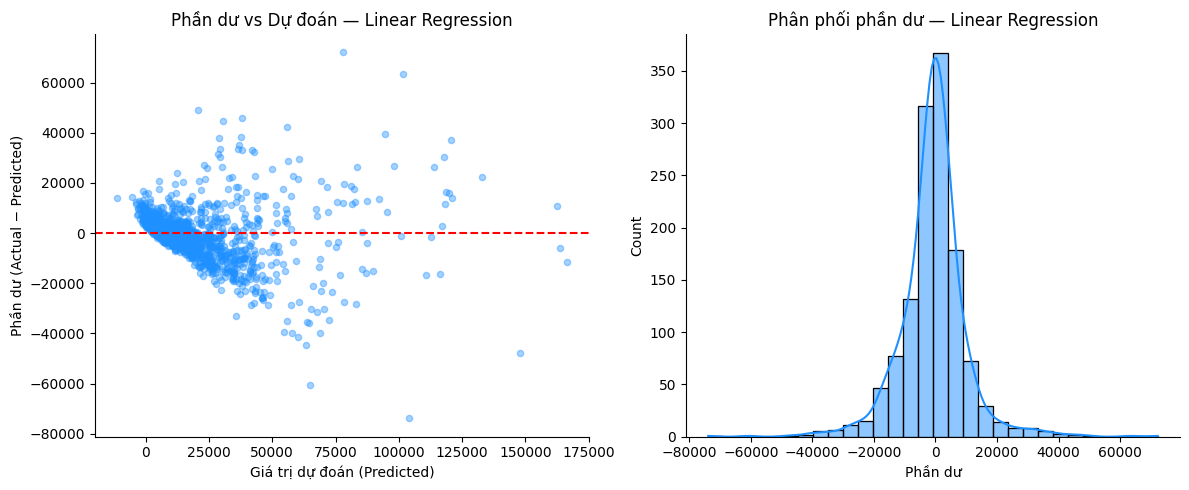

In [198]:
# ──────────────────────────────────────────────────────────────
# ĐÁNH GIÁ PHẦN DƯ – LINEAR REGRESSION (tỷ lệ 6:4)
# ──────────────────────────────────────────────────────────────
y_test_lr = saved_results["Linear Regression"]["y_test"]
y_pred_lr = saved_results["Linear Regression"]["y_pred"]

# Phần dư = Thực tế - Dự đoán (nếu mô hình tốt, phần dư xấp xỉ 0 và phân bố ngẫu nhiên)
residuals = y_test_lr - y_pred_lr

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Scatter: phần dư vs giá trị dự đoán
ax1.scatter(y_pred_lr, residuals, alpha=0.4, color='dodgerblue', s=20)
ax1.axhline(0, color='red', linestyle='--')
ax1.set_xlabel('Giá trị dự đoán (Predicted)')
ax1.set_ylabel('Phần dư (Actual − Predicted)')
ax1.set_title('Phần dư vs Dự đoán — Linear Regression')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Histogram phân bố phần dư
sns.histplot(residuals, kde=True, bins=30, ax=ax2, color='dodgerblue')
ax2.set_title('Phân phối phần dư — Linear Regression')
ax2.set_xlabel('Phần dư')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


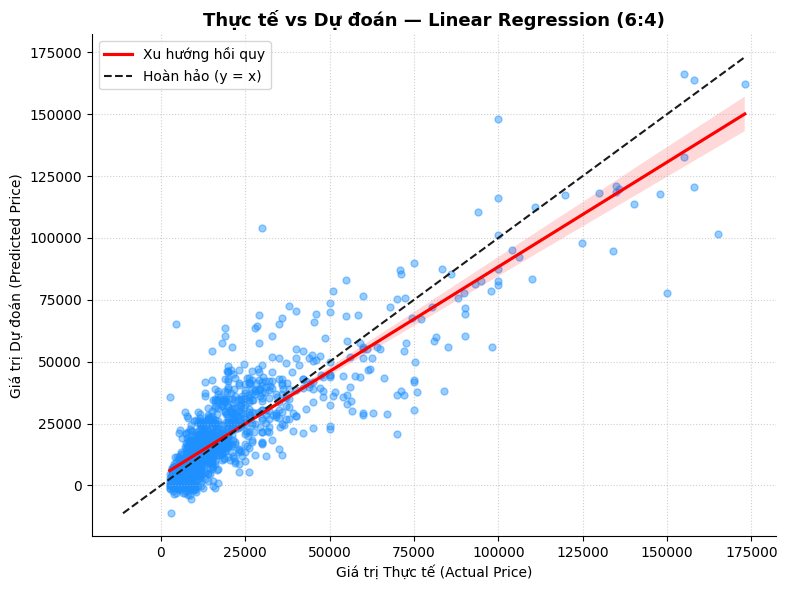

In [199]:
# ──────────────────────────────────────────────────────────────
# THỰC TẾ vs DỰ ĐOÁN – LINEAR REGRESSION (tỷ lệ 6:4)
# ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))

# Vẽ scatter + đường hồi quy xu hướng
sns.regplot(
    x=y_test_lr, y=y_pred_lr, ax=ax,
    scatter_kws={'alpha': 0.45, 'color': 'dodgerblue', 's': 25},
    line_kws={'color': 'red', 'label': 'Xu hướng hồi quy'}
)

# Đường lý tưởng y = x (dự đoán hoàn hảo)
lo, hi = min(y_test_lr.min(), y_pred_lr.min()), max(y_test_lr.max(), y_pred_lr.max())
ax.plot([lo, hi], [lo, hi], 'k--', label='Hoàn hảo (y = x)')

ax.set_xlabel('Giá trị Thực tế (Actual Price)')
ax.set_ylabel('Giá trị Dự đoán (Predicted Price)')
ax.set_title('Thực tế vs Dự đoán — Linear Regression (6:4)', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, linestyle=':', alpha=0.6)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


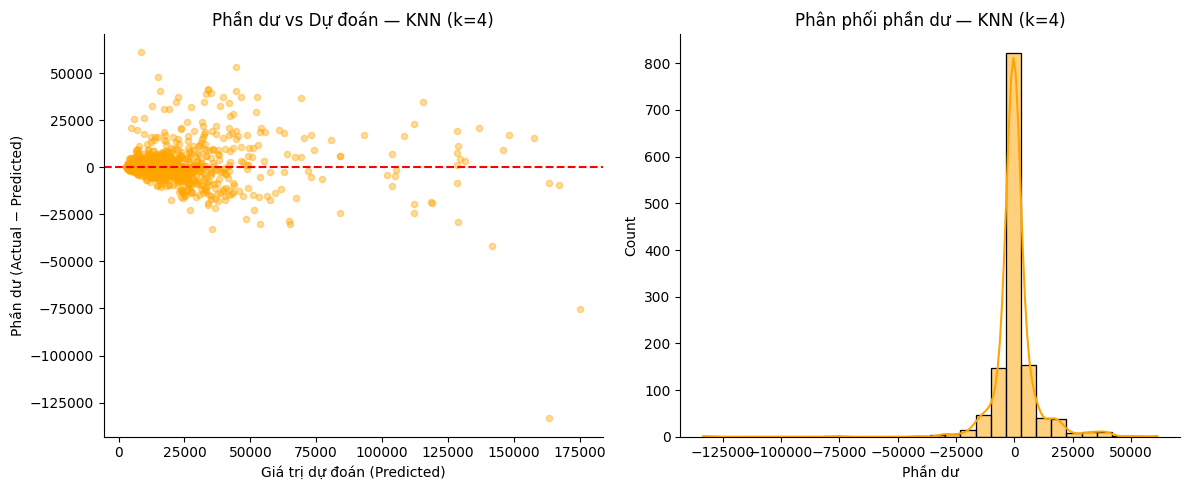

In [200]:
# ──────────────────────────────────────────────────────────────
# ĐÁNH GIÁ PHẦN DƯ – KNN TỐI ƯU (tỷ lệ 6:4)
# ──────────────────────────────────────────────────────────────
knn_key = [k for k in saved_results if 'KNN' in k][0]   # lấy đúng key dù k thay đổi
y_test_knn = saved_results[knn_key]["y_test"]
y_pred_knn = saved_results[knn_key]["y_pred"]

residuals_knn = y_test_knn - y_pred_knn

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Scatter phần dư
ax1.scatter(y_pred_knn, residuals_knn, alpha=0.4, color='orange', s=20)
ax1.axhline(0, color='red', linestyle='--')
ax1.set_xlabel('Giá trị dự đoán (Predicted)')
ax1.set_ylabel('Phần dư (Actual − Predicted)')
ax1.set_title(f'Phần dư vs Dự đoán — {knn_key}')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Histogram phân bố phần dư
sns.histplot(residuals_knn, kde=True, bins=30, ax=ax2, color='orange')
ax2.set_title(f'Phân phối phần dư — {knn_key}')
ax2.set_xlabel('Phần dư')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


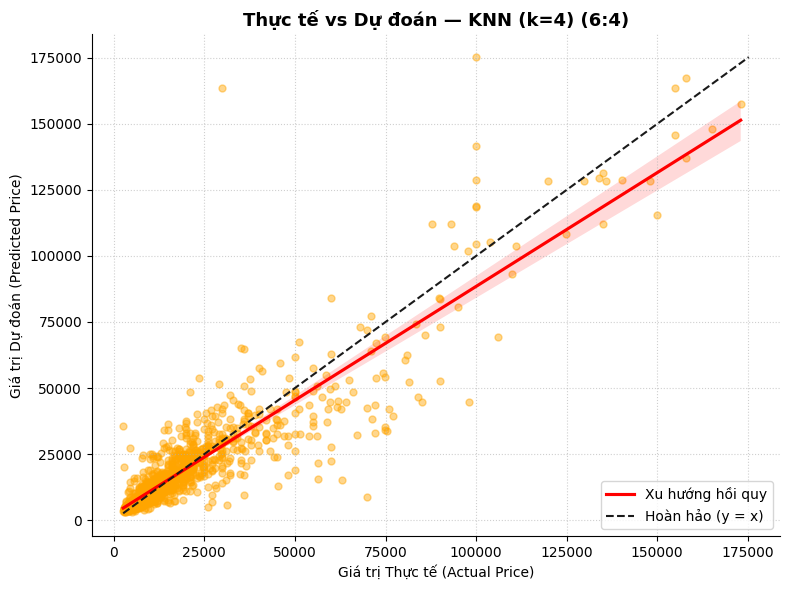

In [201]:
# ──────────────────────────────────────────────────────────────
# THỰC TẾ vs DỰ ĐOÁN – KNN TỐI ƯU (tỷ lệ 6:4)
# ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))

sns.regplot(
    x=y_test_knn, y=y_pred_knn, ax=ax,
    scatter_kws={'alpha': 0.45, 'color': 'orange', 's': 25},
    line_kws={'color': 'red', 'label': 'Xu hướng hồi quy'}
)

lo, hi = min(y_test_knn.min(), y_pred_knn.min()), max(y_test_knn.max(), y_pred_knn.max())
ax.plot([lo, hi], [lo, hi], 'k--', label='Hoàn hảo (y = x)')

ax.set_xlabel('Giá trị Thực tế (Actual Price)')
ax.set_ylabel('Giá trị Dự đoán (Predicted Price)')
ax.set_title(f'Thực tế vs Dự đoán — {knn_key} (6:4)', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, linestyle=':', alpha=0.6)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


[K-Means] K tối ưu = 3  |  Silhouette = 0.1183


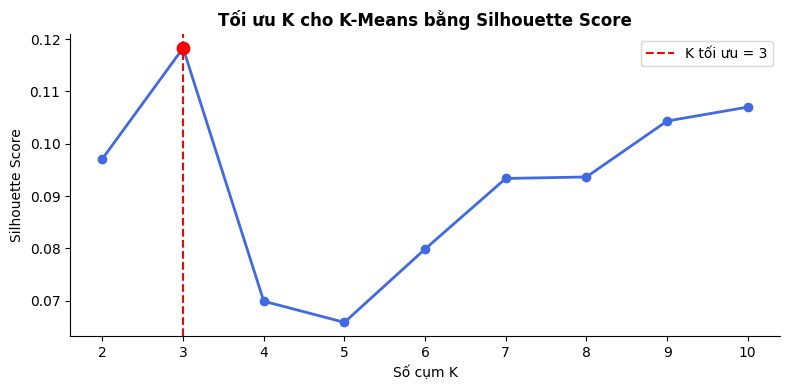


Phân bố cụm K-Means (K=3):
KMeans_Cluster
0     120
1    1491
2    1648
Name: count, dtype: int64


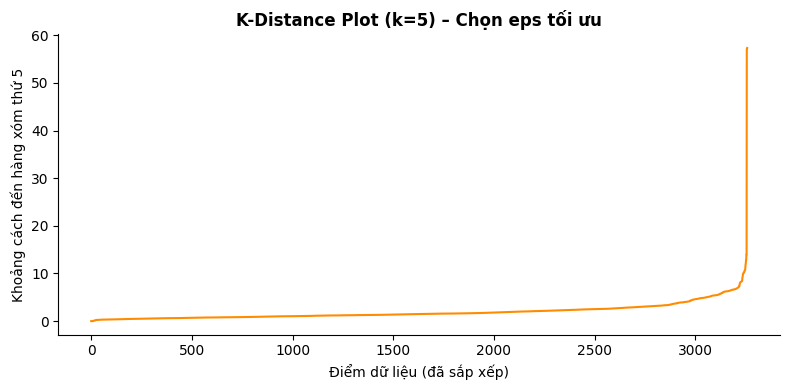


[DBSCAN] eps tối ưu (tự động) = 6.711  |  min_samples = 5
Số cụm tìm được: 32  |  Điểm nhiễu: 38 (1.2%)

Phân bố cụm DBSCAN (eps=6.711):
DBSCAN_Cluster
-1       38
 0     1763
 1       35
 2       72
 3       84
 4       90
 5       67
 6      120
 7       23
 8      100
 9       15
 10      57
 11      70
 12      19
 13      60
 14      32
 15      40
 16      44
 17       9
 18      33
 19      82
 20       6
 21      30
 22      14
 23      35
 24      59
 25      58
 26      28
 27      21
 28      63
 29      41
 30      36
 31      15
Name: count, dtype: int64


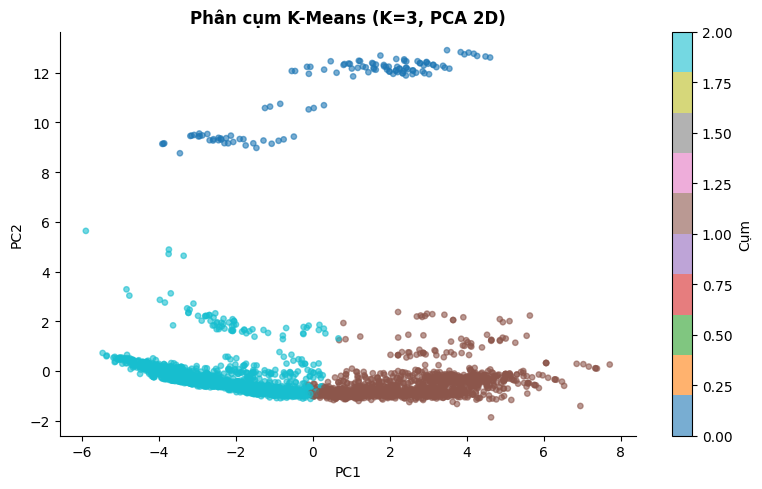

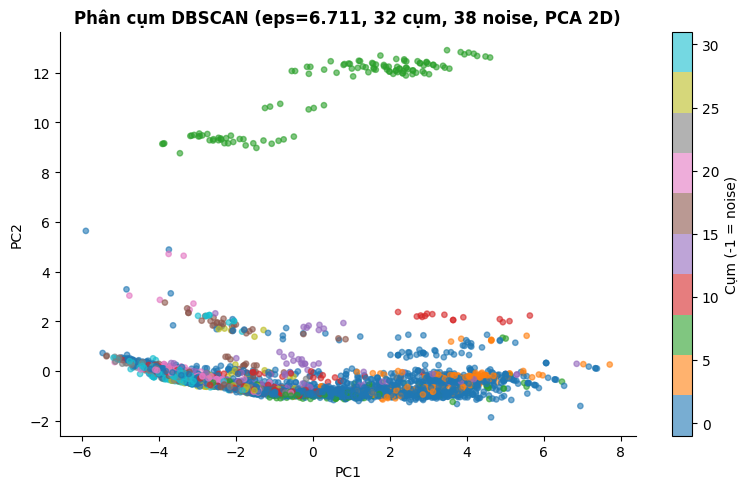

In [202]:
# ══════════════════════════════════════════════════════════════
# 1.4 PHÂN CỤM DỮ LIỆU
# ══════════════════════════════════════════════════════════════
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

# ── Chuẩn bị dữ liệu ──────────────────────────────────────────
# Chỉ dùng các đặc trưng số, chuẩn hóa để các thuật toán
# phân cụm không bị ảnh hưởng bởi đơn vị khác nhau
X_num = df.select_dtypes(include=[np.number]).drop(columns=['Price'])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_num)


# ══════════════════════════════════════════════════════════════
# PHẦN A: K-MEANS – Tối ưu K bằng hệ số Silhouette
# ══════════════════════════════════════════════════════════════

# Thử các giá trị K từ 2 đến 10 và tính Silhouette Score cho từng K.
# Silhouette Score ∈ [-1, 1]: càng gần 1 thì cụm càng tách biệt & gọn.
K_range = range(2, 11)
sil_scores = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, labels))

# Chọn K cho điểm Silhouette cao nhất
best_k = K_range.start + np.argmax(sil_scores)
print(f"[K-Means] K tối ưu = {best_k}  |  Silhouette = {max(sil_scores):.4f}")

# Vẽ biểu đồ Silhouette Score theo K
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(list(K_range), sil_scores, marker='o', color='royalblue', linewidth=2)
ax.axvline(best_k, color='red', linestyle='--', label=f'K tối ưu = {best_k}')
ax.scatter([best_k], [max(sil_scores)], color='red', zorder=5, s=80)
ax.set_xlabel('Số cụm K')
ax.set_ylabel('Silhouette Score')
ax.set_title('Tối ưu K cho K-Means bằng Silhouette Score', fontweight='bold')
ax.legend(); ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()

# Huấn luyện K-Means với K tối ưu và lưu nhãn cụm
kmeans_best = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df['KMeans_Cluster'] = kmeans_best.fit_predict(X_scaled)
print(f"\nPhân bố cụm K-Means (K={best_k}):")
print(df['KMeans_Cluster'].value_counts().sort_index())


# ══════════════════════════════════════════════════════════════
# PHẦN B: DBSCAN – Tìm eps tối ưu bằng biểu đồ K-Distance
# ══════════════════════════════════════════════════════════════

# K-Distance plot: với mỗi điểm, tính khoảng cách đến hàng xóm thứ k gần nhất
# (thường dùng k = 2*số_chiều - 1 hoặc một giá trị cố định như 4/5).
# Điểm "khuỷu tay" (elbow) trên biểu đồ là eps tối ưu.
min_samples = 5  # ngưỡng số điểm tối thiểu trong vùng lân cận

nbrs = NearestNeighbors(n_neighbors=min_samples).fit(X_scaled)
distances, _ = nbrs.kneighbors(X_scaled)

# Lấy khoảng cách đến hàng xóm xa nhất (cột cuối) rồi sắp xếp tăng dần
k_distances = np.sort(distances[:, -1])

# Vẽ K-Distance plot để xác định eps
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(k_distances, color='darkorange', linewidth=1.5)
ax.set_xlabel('Điểm dữ liệu (đã sắp xếp)')
ax.set_ylabel(f'Khoảng cách đến hàng xóm thứ {min_samples}')
ax.set_title(f'K-Distance Plot (k={min_samples}) – Chọn eps tối ưu', fontweight='bold')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()

# ── Tự động xác định điểm elbow làm eps ──────────────────────
# Dùng phương pháp đường thẳng nối hai đầu: điểm xa đường nhất = elbow
p1 = np.array([0, k_distances[0]])
p2 = np.array([len(k_distances) - 1, k_distances[-1]])
line_vec  = p2 - p1
line_len  = np.linalg.norm(line_vec)
proj      = np.array([np.dot(np.array([i, k_distances[i]]) - p1, line_vec) / line_len
                      for i in range(len(k_distances))])
perp_dist = np.abs(np.array([k_distances[i] - (p1[1] + proj[i] * line_vec[1] / line_len)
                              for i in range(len(k_distances))]))
eps_opt   = round(k_distances[np.argmax(perp_dist)], 3)
print(f"\n[DBSCAN] eps tối ưu (tự động) = {eps_opt}  |  min_samples = {min_samples}")

# ── Chạy DBSCAN với eps tối ưu ───────────────────────────────
db = DBSCAN(eps=eps_opt, min_samples=min_samples)
df['DBSCAN_Cluster'] = db.fit_predict(X_scaled)  # nhãn -1 = nhiễu (noise)

n_clusters_db = len(set(df['DBSCAN_Cluster'])) - (1 if -1 in df['DBSCAN_Cluster'].values else 0)
n_noise       = (df['DBSCAN_Cluster'] == -1).sum()
print(f"Số cụm tìm được: {n_clusters_db}  |  Điểm nhiễu: {n_noise} ({n_noise/len(df)*100:.1f}%)")
print(f"\nPhân bố cụm DBSCAN (eps={eps_opt}):")
print(df['DBSCAN_Cluster'].value_counts().sort_index())


# ══════════════════════════════════════════════════════════════
# PHẦN C: TRỰC QUAN HÓA KẾT QUẢ PHÂN CỤM
# ══════════════════════════════════════════════════════════════

# Dùng 2 thành phần PCA đầu tiên để chiếu dữ liệu xuống 2D
from sklearn.decomposition import PCA as _PCA
X_2d = _PCA(n_components=2, random_state=42).fit_transform(X_scaled)

# ── Biểu đồ K-Means ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
sc = ax.scatter(X_2d[:, 0], X_2d[:, 1],
                c=df['KMeans_Cluster'], cmap='tab10', s=15, alpha=0.6)
ax.set_title(f'Phân cụm K-Means (K={best_k}, PCA 2D)', fontweight='bold')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.spines[['top','right']].set_visible(False)
plt.colorbar(sc, ax=ax, label='Cụm')
plt.tight_layout(); plt.show()

# ── Biểu đồ DBSCAN ────────────────────────────────────────────
# Điểm nhiễu (nhãn -1) sẽ hiển thị màu tím/đen tách biệt
colors_db = df['DBSCAN_Cluster'].map(lambda x: x if x >= 0 else -1)
fig, ax = plt.subplots(figsize=(8, 5))
sc = ax.scatter(X_2d[:, 0], X_2d[:, 1],
                c=colors_db, cmap='tab10', s=15, alpha=0.6)
ax.set_title(f'Phân cụm DBSCAN (eps={eps_opt}, {n_clusters_db} cụm, {n_noise} noise, PCA 2D)',
             fontweight='bold')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.spines[['top','right']].set_visible(False)
plt.colorbar(sc, ax=ax, label='Cụm (-1 = noise)')
plt.tight_layout(); plt.show()

── Ngưỡng phân chia giá ──
  [Low]  2,500 – 8,700   →  1087 mẫu
  [Medium]  8,700 – 17,799   →  1085 mẫu
  [High]  17,799 – 200,999   →  1087 mẫu

Tổng mẫu: 3259  |  Phân bố:
Price_Class
Low       1087
Medium    1085
High      1087
Name: count, dtype: int64

Số chiều gốc: 70  →  PCA giữ lại: 23 chiều

── BẢNG KẾT QUẢ PHÂN LOẠI ──
Mô hình                | Tỷ lệ |   Acc Gốc |   Acc PCA
──────────────────────────────────────────────────────
Logistic Regression    | 8:2   |   0.8144 |   0.7853
Logistic Regression    | 7:3   |   0.8139 |   0.7894
Logistic Regression    | 6:4   |   0.8037 |   0.7784
──────────────────────────────────────────────────────
Gaussian Naive Bayes   | 8:2   |   0.5506 |   0.6794
Gaussian Naive Bayes   | 7:3   |   0.5491 |   0.7004
Gaussian Naive Bayes   | 6:4   |   0.5706 |   0.7032
──────────────────────────────────────────────────────


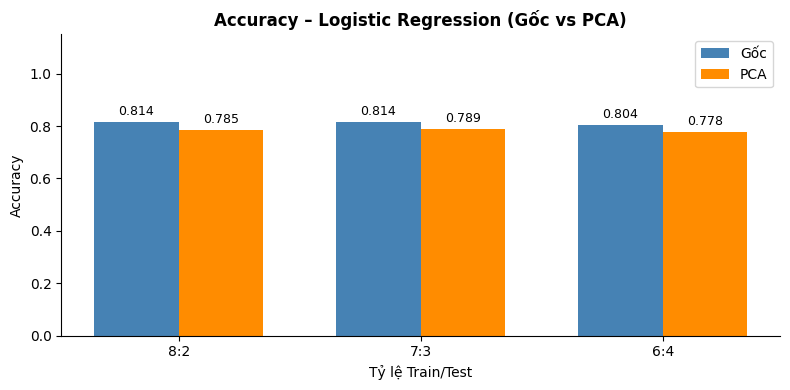

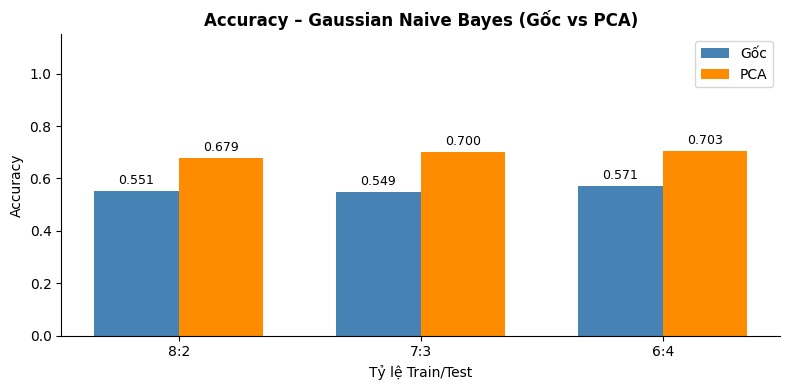

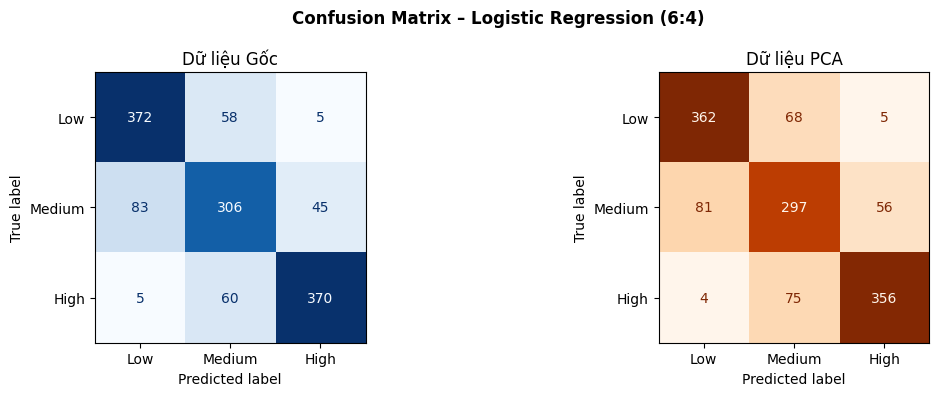


── Classification Report – Logistic Regression | Dữ liệu Gốc (6:4) ──
              precision    recall  f1-score   support

         Low       0.81      0.86      0.83       435
      Medium       0.72      0.71      0.71       434
        High       0.88      0.85      0.87       435

    accuracy                           0.80      1304
   macro avg       0.80      0.80      0.80      1304
weighted avg       0.80      0.80      0.80      1304

── Classification Report – Logistic Regression | Dữ liệu PCA (6:4) ──
              precision    recall  f1-score   support

         Low       0.81      0.83      0.82       435
      Medium       0.68      0.68      0.68       434
        High       0.85      0.82      0.84       435

    accuracy                           0.78      1304
   macro avg       0.78      0.78      0.78      1304
weighted avg       0.78      0.78      0.78      1304



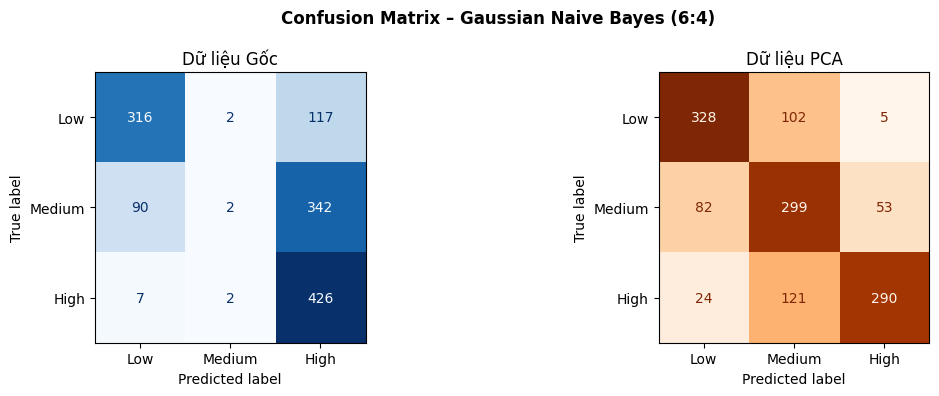


── Classification Report – Gaussian Naive Bayes | Dữ liệu Gốc (6:4) ──
              precision    recall  f1-score   support

         Low       0.77      0.73      0.75       435
      Medium       0.33      0.00      0.01       434
        High       0.48      0.98      0.65       435

    accuracy                           0.57      1304
   macro avg       0.53      0.57      0.47      1304
weighted avg       0.53      0.57      0.47      1304

── Classification Report – Gaussian Naive Bayes | Dữ liệu PCA (6:4) ──
              precision    recall  f1-score   support

         Low       0.76      0.75      0.75       435
      Medium       0.57      0.69      0.63       434
        High       0.83      0.67      0.74       435

    accuracy                           0.70      1304
   macro avg       0.72      0.70      0.71      1304
weighted avg       0.72      0.70      0.71      1304



In [203]:
# ══════════════════════════════════════════════════════════════
# 1.5 PHÂN LOẠI DỰA TRÊN KẾT QUẢ PHÂN CỤM
# ══════════════════════════════════════════════════════════════
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, classification_report,
                             ConfusionMatrixDisplay)

# ══════════════════════════════════════════════════════════════
# BƯỚC 1: CHIA GIÁ THÀNH 3 KHOẢNG CÂN BẰNG MẪU (QUANTILE)
# ══════════════════════════════════════════════════════════════

# Dùng pd.qcut để chia Price thành 3 khoảng sao cho số mẫu xấp xỉ nhau.
# duplicates='drop' xử lý trường hợp nhiều giá trị Price trùng nhau tại ranh giới.
df['Price_Class'], bins = pd.qcut(
    df['Price'], q=3,
    labels=['Low', 'Medium', 'High'],
    retbins=True,          # trả về ngưỡng phân chia
    duplicates='drop'
)

# In ngưỡng và phân bố từng lớp
print("── Ngưỡng phân chia giá ──")
for i, (lo, hi) in enumerate(zip(bins[:-1], bins[1:])):
    label = ['Low', 'Medium', 'High'][i]
    count = (df['Price_Class'] == label).sum()
    print(f"  [{label}]  {lo:,.0f} – {hi:,.0f}   →  {count} mẫu")

print(f"\nTổng mẫu: {len(df)}  |  Phân bố:")
print(df['Price_Class'].value_counts().sort_index())


# ══════════════════════════════════════════════════════════════
# BƯỚC 2: CHUẨN BỊ DỮ LIỆU & GIẢM CHIỀU PCA (1/3 CHIỀU GỐC)
# ══════════════════════════════════════════════════════════════

# Dùng X (đặc trưng số) đã có từ mục 1.3; y_cls là nhãn phân loại mới
X_cls = df.select_dtypes(include=[np.number]).drop(columns=['Price', 'KMeans_Cluster', 'DBSCAN_Cluster'],
                                                    errors='ignore')
y_cls = df['Price_Class']

n_reduced = int(X_cls.shape[1] / 3)   # 1/3 số chiều gốc (giống mục 1.3)
print(f"\nSố chiều gốc: {X_cls.shape[1]}  →  PCA giữ lại: {n_reduced} chiều")

splits     = [0.2, 0.3, 0.4]
split_lbl  = ['8:2', '7:3', '6:4']

models_cls = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Gaussian Naive Bayes': GaussianNB()
}


# ══════════════════════════════════════════════════════════════
# BƯỚC 3: HUẤN LUYỆN & ĐÁNH GIÁ TRÊN 3 TỶ LỆ CHIA
# ══════════════════════════════════════════════════════════════

# Lưu kết quả để vẽ biểu đồ và in bảng
results = []   # mỗi phần tử: (model_name, ratio, data_type, accuracy)
best_cm = {}   # lưu confusion matrix tỷ lệ 6:4 để vẽ

print("\n── BẢNG KẾT QUẢ PHÂN LOẠI ──")
header = f"{'Mô hình':<22} | {'Tỷ lệ':<5} | {'Acc Gốc':>9} | {'Acc PCA':>9}"
print(header); print('─' * len(header))

for name, model in models_cls.items():
    for split, ratio in zip(splits, split_lbl):

        # ── Chia dữ liệu ─────────────────────────────────────
        X_tr, X_te, y_tr, y_te = train_test_split(
            X_cls, y_cls, test_size=split, random_state=42, stratify=y_cls
        )

        # ── Chuẩn hóa (fit chỉ trên train) ───────────────────
        sc = StandardScaler()
        X_tr_s = sc.fit_transform(X_tr)
        X_te_s = sc.transform(X_te)

        # ── PCA fit chỉ trên train (tránh data leakage) ──────
        pca_s = PCA(n_components=n_reduced, random_state=42)
        X_tr_p = pca_s.fit_transform(X_tr_s)
        X_te_p = pca_s.transform(X_te_s)

        # ── Huấn luyện & đánh giá trên dữ liệu GỐC ──────────
        model.fit(X_tr_s, y_tr)
        acc_ori = accuracy_score(y_te, model.predict(X_te_s))

        # ── Huấn luyện & đánh giá trên dữ liệu PCA ──────────
        model.fit(X_tr_p, y_tr)
        acc_pca = accuracy_score(y_te, model.predict(X_te_p))
        y_pred_pca = model.predict(X_te_p)

        # Lưu kết quả
        results.append((name, ratio, 'Gốc', acc_ori))
        results.append((name, ratio, 'PCA', acc_pca))

        print(f"{name:<22} | {ratio:<5} | {acc_ori:>8.4f} | {acc_pca:>8.4f}")

        # Lưu confusion matrix tỷ lệ 6:4 (split=0.4) để vẽ
        if split == 0.4:
            best_cm[name] = {
                'y_te': y_te,
                'y_pred_ori': model.fit(X_tr_s, y_tr).predict(X_te_s),
                'y_pred_pca': y_pred_pca,
                'labels': model.classes_ if hasattr(model, 'classes_') else sorted(y_cls.unique())
            }

    print('─' * len(header))


# ══════════════════════════════════════════════════════════════
# BƯỚC 4: BIỂU ĐỒ SO SÁNH ACCURACY
# ══════════════════════════════════════════════════════════════

df_res = pd.DataFrame(results, columns=['Model', 'Ratio', 'Data', 'Accuracy'])

for name in models_cls:
    sub = df_res[df_res['Model'] == name]
    ori = sub[sub['Data'] == 'Gốc']['Accuracy'].values
    pca = sub[sub['Data'] == 'PCA']['Accuracy'].values

    x   = np.arange(len(split_lbl))
    w   = 0.35

    fig, ax = plt.subplots(figsize=(8, 4))
    b1 = ax.bar(x - w/2, ori, w, label='Gốc',  color='steelblue')
    b2 = ax.bar(x + w/2, pca, w, label='PCA',  color='darkorange')
    ax.bar_label(b1, fmt='%.3f', padding=3, fontsize=9)
    ax.bar_label(b2, fmt='%.3f', padding=3, fontsize=9)
    ax.set_xticks(x); ax.set_xticklabels(split_lbl)
    ax.set_xlabel('Tỷ lệ Train/Test')
    ax.set_ylabel('Accuracy')
    ax.set_ylim(0, 1.15)
    ax.set_title(f'Accuracy – {name} (Gốc vs PCA)', fontweight='bold')
    ax.legend(); ax.spines[['top','right']].set_visible(False)
    plt.tight_layout(); plt.show()


# ══════════════════════════════════════════════════════════════
# BƯỚC 5: CONFUSION MATRIX (tỷ lệ 6:4)
# ══════════════════════════════════════════════════════════════

class_order = ['Low', 'Medium', 'High']

for name, cm_data in best_cm.items():
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(f'Confusion Matrix – {name} (6:4)', fontweight='bold')

    ConfusionMatrixDisplay.from_predictions(
        cm_data['y_te'], cm_data['y_pred_ori'],
        labels=class_order, ax=ax1, colorbar=False, cmap='Blues'
    )
    ax1.set_title('Dữ liệu Gốc')

    ConfusionMatrixDisplay.from_predictions(
        cm_data['y_te'], cm_data['y_pred_pca'],
        labels=class_order, ax=ax2, colorbar=False, cmap='Oranges'
    )
    ax2.set_title('Dữ liệu PCA')

    plt.tight_layout(); plt.show()

    # In classification report chi tiết
    print(f"\n── Classification Report – {name} | Dữ liệu Gốc (6:4) ──")
    print(classification_report(cm_data['y_te'], cm_data['y_pred_ori'],
                                labels=class_order, zero_division=0))
    print(f"── Classification Report – {name} | Dữ liệu PCA (6:4) ──")
    print(classification_report(cm_data['y_te'], cm_data['y_pred_pca'],
                                labels=class_order, zero_division=0))